In [1]:
import numpy as  np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import *

In [2]:
df = pd.read_csv('../../data/job_salary_prediction_dataset.csv')

In [3]:
X = df.drop('salary', axis=1)
y = df['salary']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)

In [5]:
# Binerizer 

df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


In [6]:
df['certifications'].unique()

array([2, 0, 1, 3, 5, 4])

In [18]:
binn= Binarizer(threshold=3)

In [19]:
binn.fit_transform(X_train[['certifications']])

array([[0],
       [1],
       [1],
       ...,
       [0],
       [0],
       [0]], shape=(175000, 1))

In [20]:
binn.transform(X_test[['certifications']])

array([[0],
       [0],
       [1],
       ...,
       [0],
       [1],
       [0]], shape=(75000, 1))

In [21]:
binn.threshold

3

In [17]:
binn.feature_names_in_

array(['certifications'], dtype=object)

In [23]:
# binning 
df['cert_range'] = pd.cut(df['certifications'], 4) 

In [24]:
df[['cert_range', 'certifications']]

,cert_range,certifications
0,"(1.25, 2.5]",2
1,"(-0.005, 1.25]",0
2,"(-0.005, 1.25]",1
3,"(-0.005, 1.25]",0
4,"(-0.005, 1.25]",0
...,...,...
249995,"(-0.005, 1.25]",1
249996,"(1.25, 2.5]",2
249997,"(-0.005, 1.25]",0
249998,"(3.75, 5.0]",5


In [36]:
obj = KBinsDiscretizer(n_bins=4, encode='ordinal')

In [37]:
obj.fit_transform(X_train[['certifications']])

E:\class_repos\DataScience_Morning\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


array([[2.],
       [3.],
       [3.],
       ...,
       [0.],
       [2.],
       [2.]], shape=(175000, 1))

In [38]:
# obj.inverse_transform()
obj.bin_edges_

array([array([0., 1., 2., 4., 5.])], dtype=object)

In [39]:
# Data Transformation 
# Log 
transformer = FunctionTransformer(func=np.log1p) # Log transformation 

In [41]:
transformer.fit_transform(pd.DataFrame(y_train))

,salary
192448,11.706426
139604,12.213068
140914,12.067138
80088,11.876804
72918,11.733385
...,...
119879,11.225217
103694,11.949637
131932,11.781944
146867,11.374537


In [ ]:
# class FunctionTransformer:
#     def __init__():
#         pass
#     def transfrom
#     def fit_transform
#     def fit 

In [67]:
# powertransformer : box-cox, 
# arr = np.array([[ 1,2,3,4, 1000]])
# arr = np.random.rand(1, 100)
obj = PowerTransformer()


In [68]:
arr = obj.fit_transform(pd.DataFrame(y_train))

<Axes: ylabel='Density'>

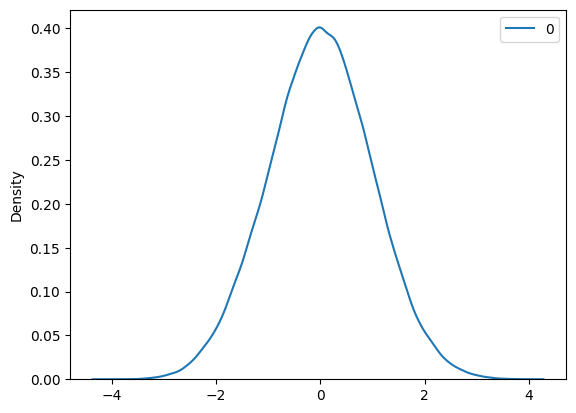

In [69]:
sns.kdeplot(arr)